In [13]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon
!pip install meshio

Defaulting to user installation because normal site-packages is not writeable
     ------------------------------------ 166.2/166.2 kB 715.2 kB/s eta 0:00:00
     -------------------------------------- 241.6/241.6 kB 7.2 MB/s eta 0:00:00
     ---------------------------------------- 1.2/1.2 MB 19.3 MB/s eta 0:00:00
     ---------------------------------------- 87.5/87.5 kB 4.8 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
# Load the DFSU file and extract the desired item
mesh_file = r"D:\dipen\Prototype_domain_without_river_network_utm.mesh"
shapefile_path = r'D:\dipen\land_Part_area_utm.zip'
ds = mikeio.open(mesh_file)
bathymetry = ds.node_coordinates[:, 2] 
bathymetry[:10]
# data = ds.read(items="Statistical maximum : Total water depth") 


array([4.02660179, 4.05034494, 3.97377133, 3.83951235, 3.80859804,
       4.04982138, 3.78972435, 3.69740939, 3.54975343, 4.09204817])

In [15]:
import mikeio
from mikeio import Mesh
import geopandas as gpd
from shapely.geometry import Point
import meshio

# Load the mesh file
mesh_file = r"D:\dipen\Prototype_domain_without_river_network_utm.mesh"
mesh = Mesh(mesh_file)

# Load the shapefile
shapefile_path = r'D:\dipen\land_Part_area_utm.zip'
shape = gpd.read_file(shapefile_path)

# Ensure the shapefile and mesh are in the same coordinate system
# (Check the CRS and reproject if necessary)

# Access bathymetry data (Z coordinates)
bathymetry = mesh.node_coordinates[:, 2]

# Get mesh node coordinates
node_coords = mesh.node_coordinates[:, :2]

# Create Point geometries for each node
points = gpd.GeoSeries([Point(x, y) for x, y in node_coords])

# Identify nodes within the shapefile boundary
# Assume the shapefile contains one polygon, otherwise iterate over the shapes
polygon = shape.geometry.unary_union  # Merge multiple shapes if necessary

# Check which points are within the polygon
inside_polygon = points.within(polygon)

# Deduct 0.017 meters from bathymetry values for nodes within the polygon
bathymetry[inside_polygon] -= 0.017

# Update the mesh with modified bathymetry
mesh.node_coordinates[:, 2] = bathymetry



In [33]:
# Extract geometry information
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates  # This gets the node coordinates
element_table

array([array([29698,  8289, 10972]), array([18888, 21252, 11501]),
       array([57688, 28834,  7824]), ..., array([ 50690, 101839,  91736]),
       array([ 98136, 101840,  64873]), array([ 64904, 101840, 101740])],
      dtype=object)

In [37]:
# Get water depth data
water_depth = data[0].to_numpy()
water_depth

array([[0.       , 1.9731971, 5.8356504, ..., 2.7128608, 2.177164 ,
        2.121866 ]], dtype=float32)

In [6]:

# Define the threshold value
threshold = 0.1  # meters

In [7]:
# Identify elements where water depth exceeds the threshold
flooded_elements = np.where(water_depth > threshold)[1]

In [8]:
flooded_elements

array([     1,      2,      6, ..., 203085, 203086, 203087], dtype=int64)

In [39]:
nodes = element_table[203087]  # zero-index correction
coords = node_coordinates[nodes]
coords

array([[ 6.60250121e+05,  3.02445004e+06, -9.87099290e-01],
       [ 6.60111906e+05,  3.02456240e+06, -1.03213358e+00],
       [ 6.60070806e+05,  3.02439486e+06, -1.20012784e+00]])

In [45]:
# Create polygons for flooded elements
flooded_polygons = []
for elem_idx in flooded_elements:
  #print(elem_idx)
  nodes = element_table[elem_idx]  # zero-index correction
  coords = node_coordinates[nodes]
  flooded_polygons.append(Polygon(coords))
#flooded_polygons
# Convert polygons to a GeoDataFrame
flooded_area_gdf = gpd.GeoDataFrame(
    {'geometry': flooded_polygons},
    crs="EPSG:32614"  # UTM Zone 14N
)


<AxesSubplot: >

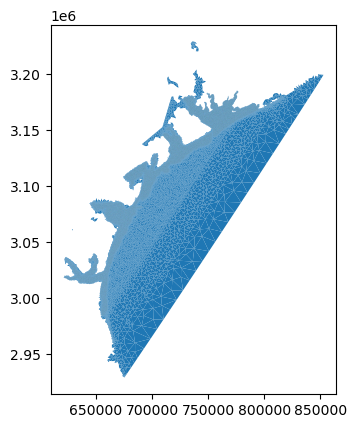

In [46]:
flooded_area_gdf.plot()

In [12]:
flooded_area_gdf_ds = flooded_area_gdf.dissolve()

<AxesSubplot: >

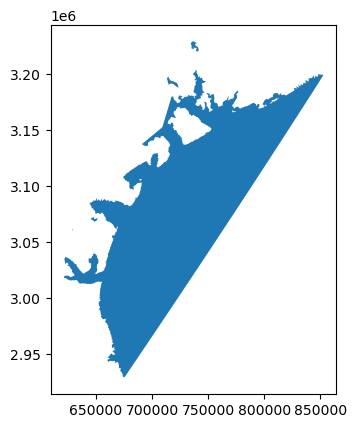

In [13]:
flooded_area_gdf_ds.plot()

In [51]:


# Clip the flooded areas with the land boundary
flooded_area_intersect = gpd.overlay(flooded_area_gdf_ds, land_boundary, how='intersection')


# Calculate the total flooded area (in square meters)
total_flooded_area = flooded_area_intersect.area

# Convert to square kilometers (if needed)
total_flooded_area_km2 = total_flooded_area / 1e6

#print(f"Total flooded area: {total_flooded_area_km2:.2f} square kilometers")

In [52]:
total_flooded_area_km2

0    1729.290082
dtype: float64

<AxesSubplot: >

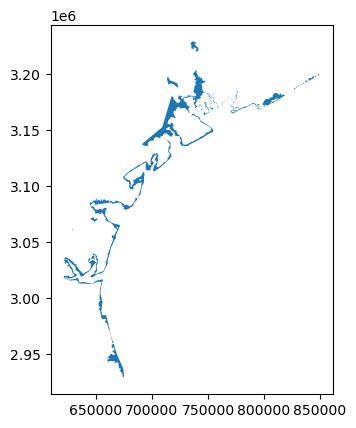

In [53]:
flooded_area_intersect.plot()